## Признаковое описание изображений
### Часть 1. Детекторы локальных особенностей

Признаковое описание изображения
- Цели, примеры применения
- Глобальные и локальные признаки

Локальные особенности изображениея
- Feature detection

Детекторы локальных особенностей
- Детектор Моравеца
- Детектор углов Харриса

Масштабно-пространственные представления изобржений

Масштабно-инвариантные детекторы 
- 𝐿𝑜𝐺-детектор
- 𝐷𝑜𝐺-детектор
- Детектор Харриса-Лапласа

In [2]:
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow # for image display
from IPython.display import display

from skimage import io
from PIL import Image
import matplotlib.pylab as plt

In [3]:
def to_uint8_image(image):
    res = (image - image.min()) * 255.0  / float(image.ptp()) + 0
    return res.astype(np.uint8)

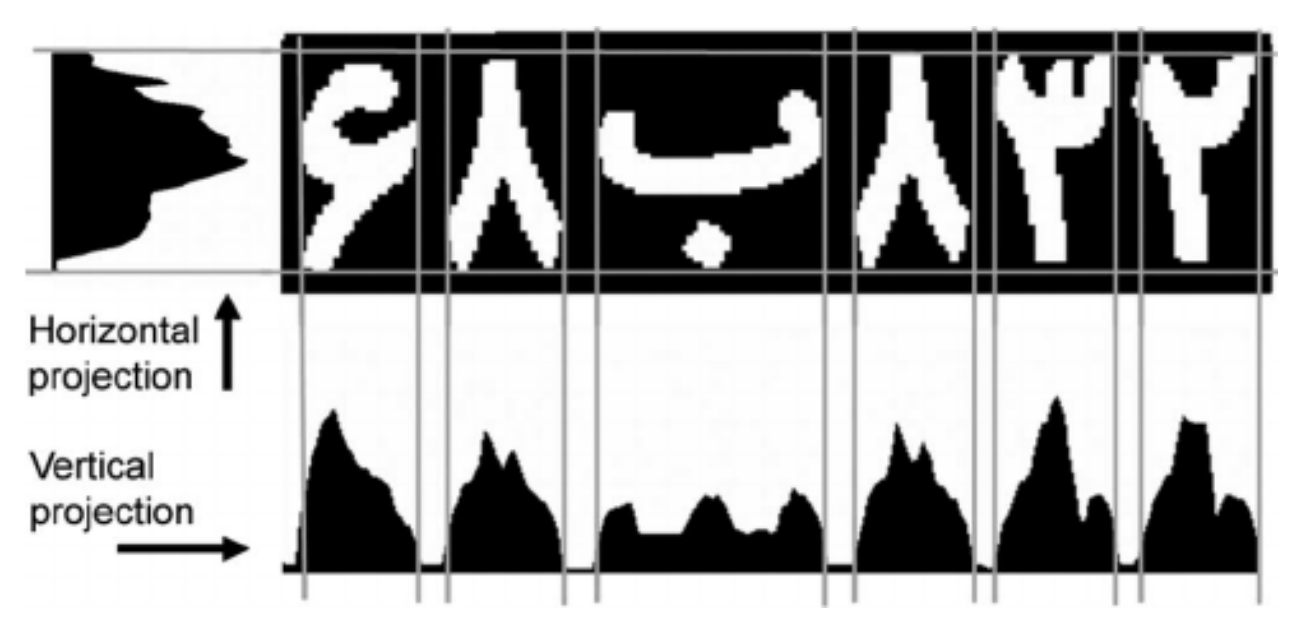

### Локальные признаки. Свойства:

- **Робастность (robustness)**
Инвариантность к масштабу, повороту, сдвигу, артефактам
сжатия изображения, шумам

- **Повторяемость (repeatability)**
Разные изображения одной и той же сцены должны иметь
одни и те же особенности, независимо от угла съемки

- **Уникальность (uniqueness)**
Особенность должна иметь единственную локализацию на
изображении

- **Точность локализации (accuracy)**
Особенность не должна иметь большие размеры

- **Количество (quantity)**
На изображении должно быть достаточное количество
локальных особенностей


### Детектор Моравеца

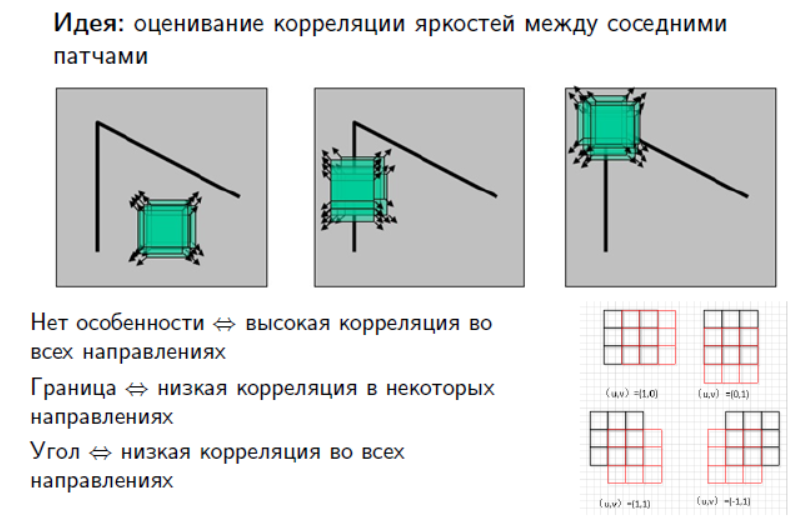

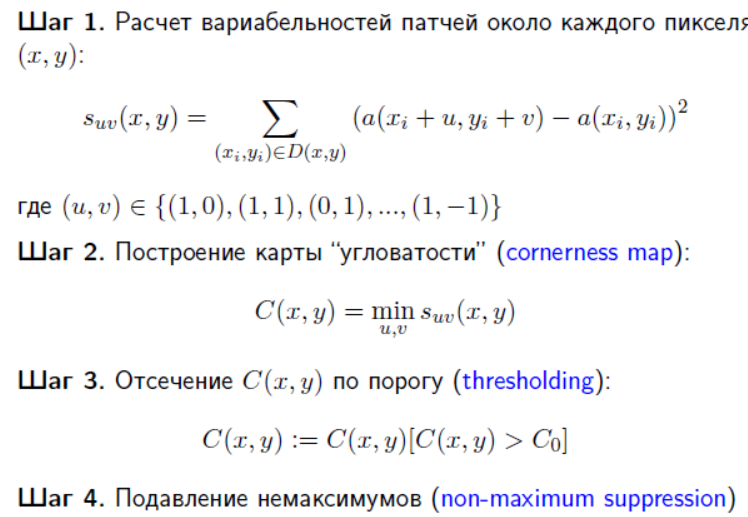

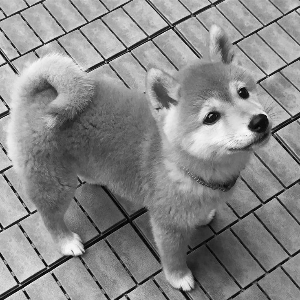

In [4]:
# url = "https://placekitten.com/360/300"
# image = io.imread(url)  # RGB
image = io.imread("./dog.jpg")
image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
image = cv2.resize(image, (300, 300))
display(Image.fromarray(image[:,:,]))

In [5]:
image.shape

(300, 300)

In [39]:
input_img = image
threshold = 100

output_img = cv2.cvtColor(input_img.copy(), cv2.COLOR_GRAY2RGB)

corners = []
xy_shifts1 = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, 1), (-1, -1), (-1, 1), (1, -1)]
xy_shifts2 = [(2, 0), (-2, 0), (0, 2), (0, -2), (2, 2), (-2, -2), (-2, 2), (2, -2)]
black1 = np.zeros((image.shape[1], image.shape[0], 3), np.uint8)
black2 = np.zeros((image.shape[1], image.shape[0], 3), np.uint8)

# для области 1
for y in range(1, image.shape[1]-1):
    for x in range(1, image.shape[0]-1):
        
        c = 100000
        suv = 0
        for shift in xy_shifts1:
            shifted_pix = int(image[y + shift[1], x + shift[0] ])
            diff = shifted_pix - image[y, x]
            diff_sq = diff ** 2
            if diff_sq < c:
                c = diff_sq
        if c > threshold:
            output_img[y, x] = (255,0,0)
            black1[y, x] = (255,0,0) 

# для области 2
for y in range(2, image.shape[1]-2):
    for x in range(2, image.shape[0]-2):
        
        c = 100000
        suv = 0
        for shift in xy_shifts2:
            shifted_pix = int(image[y + shift[1], x + shift[0] ])
            diff = shifted_pix - image[y, x]
            diff_sq = diff ** 2
            if diff_sq < c:
                c = diff_sq
        if c > threshold:
            output_img[y, x] = (255,0,0)
            black2[y, x] = (255,0,0) 
            

# TO DO Моравец с областью 3х3, 5х5

/tmp/ipykernel_83395/2368971567.py:20: RuntimeWarning: overflow encountered in scalar subtract
  diff = shifted_pix - image[y, x]
/tmp/ipykernel_83395/2368971567.py:36: RuntimeWarning: overflow encountered in scalar subtract
  diff = shifted_pix - image[y, x]


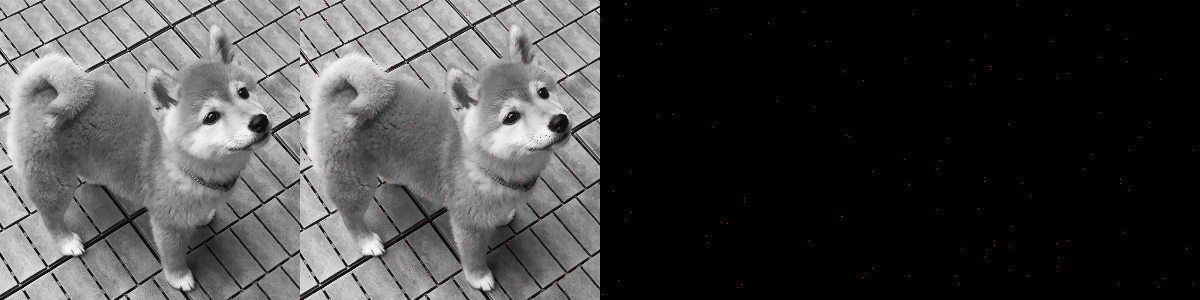

In [40]:
conc = cv2.hconcat((cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), output_img, black1, black2 ))
display(Image.fromarray(conc))

### Детектор Харриса

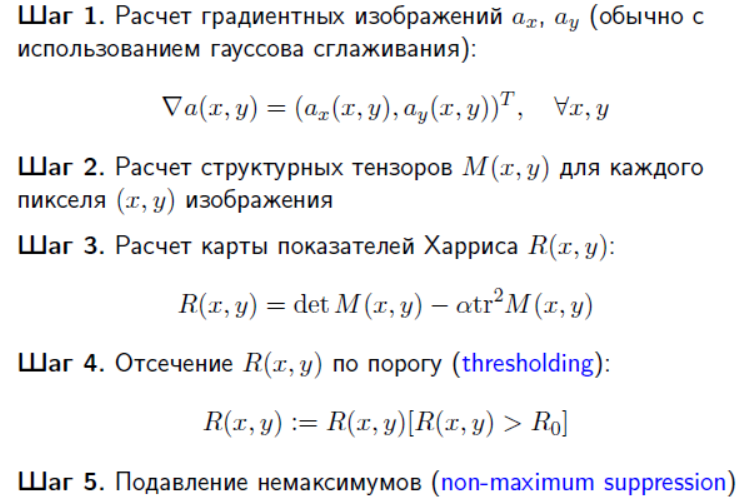

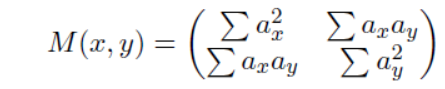

Finding Corners...


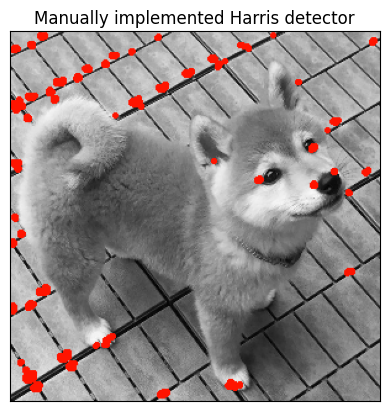

In [53]:
def my_harris(img, window_size, k, threshold):

    gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

    img_gaussian = cv2.GaussianBlur(gray, (3,3), 1.0)     # дисперсия, поизменять

    height = img.shape[0]   #.shape[0] outputs height 
    width = img.shape[1]    #.shape[1] outputs width .shape[2] outputs color channels of image
    matrix_R = np.zeros((height,width))
    
    #   Step 1 - Calculate the x e y image derivatives (dx e dy)
    dx = cv2.Sobel(img_gaussian, cv2.CV_64F, 1, 0, ksize=3)
    dy = cv2.Sobel(img_gaussian, cv2.CV_64F, 0, 1, ksize=3)
    # dy, dx = np.gradient(gray)

    #   Step 2 - Calculate product and second derivatives (dx2, dy2 e dxy)
    dx2=np.square(dx)
    dy2=np.square(dy)
    dxy=dx*dy

    offset = int( window_size / 2 )
    #   Step 3
    print ("Finding Corners...")
    for y in range(offset, height-offset):
        for x in range(offset, width-offset):
            Sx2 = np.sum(dx2[y-offset:y+1+offset, x-offset:x+1+offset])
            Sy2 = np.sum(dy2[y-offset:y+1+offset, x-offset:x+1+offset])
            Sxy = np.sum(dxy[y-offset:y+1+offset, x-offset:x+1+offset])

            #   Step 4 - Define the matrix H(x,y)=[[Sx2,Sxy],[Sxy,Sy2]]
            H = np.array([[Sx2,Sxy],[Sxy,Sy2]])
            # print(H)
            #   Step 5 - Calculate the response function ( R=det(H)-k(Trace(H))^2 )
            det=np.linalg.det(H)
            tr=np.matrix.trace(H)
            R=det-k*(tr**2)
            matrix_R[y-offset, x-offset]=R

            # eig = np.linalg.eig(H)
            # print(H, eig)

    #   Step 6 - Apply a threshold
    cv2.normalize(matrix_R, matrix_R, 0, 1, cv2.NORM_MINMAX)
    for y in range(offset, height-offset):
        for x in range(offset, width-offset):
            value=matrix_R[y, x]
            if value>threshold:
                # cornerList.append([x, y, value])
                cv2.circle(img, (x,y), 1, (255,20,0), 2)
                
    # cv2.imwrite("%s_threshold_%s.png"%(img_dir[5:-4],threshold), img)
    plt.figure("Manually implemented Harris detector")
    plt.imshow(img), plt.title("Manually implemented Harris detector")
    plt.xticks([]), plt.yticks([])
    plt.show()

my_harris(cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), 5, 0.04, 0.40) # Change this path to one that will lead to your image


In [9]:
# cv.cornerHarris(	src, blockSize, ksize, k[, dst[, borderType]]	) ->	dst
    # src	Input single-channel 8-bit or floating-point image.
    # dst	Image to store the Harris detector responses. It has the type CV_32FC1 and the same size as src .
    # blockSize	Neighborhood size (see the details on cornerEigenValsAndVecs ).
    # ksize	Aperture parameter for the Sobel operator. 
    # k	Harris detector free parameter. See the formula above.  Sensivity factor
    # borderType	Pixel extrapolation method. See BorderTypes. BORDER_WRAP is not supported


In [54]:
image_har = cv2.cornerHarris(input_img, 3, 3, 0.04)

In [55]:
input_img.shape, image_har.shape 

((300, 300), (300, 300))

In [56]:
gray = input_img
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 3, 3, 0.04)

output_img = cv2.cvtColor(input_img.copy(), cv2.COLOR_GRAY2RGB)

#result is dilated for marking the corners, not important
dst = cv2.dilate(dst, None)
# Threshold for an optimal value, it may vary depending on the image.
output_img[dst>0.25*dst.max()]=[255, 0, 0]

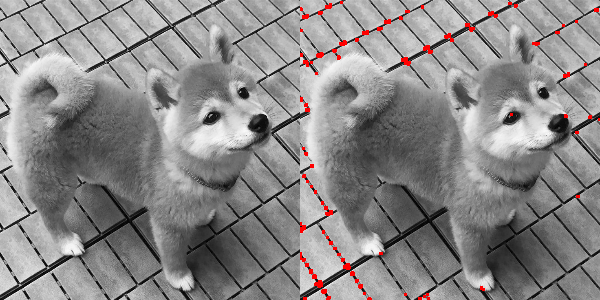

In [57]:
# conc = cv2.hconcat((cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), image_har ))
conc = cv2.hconcat((cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), output_img ))
display(Image.fromarray(conc))

### LoG, DoG

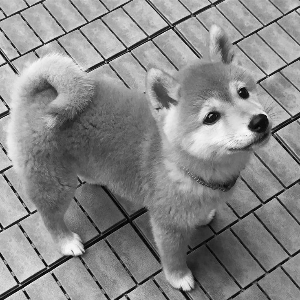

In [58]:
url = "https://placekitten.com/360/300"
# image = io.imread(url)  # RGB
image = io.imread("./dog.jpg")
image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
image = cv2.resize(image, (300, 300))
display(Image.fromarray(image[:,:,]))

input_img = image


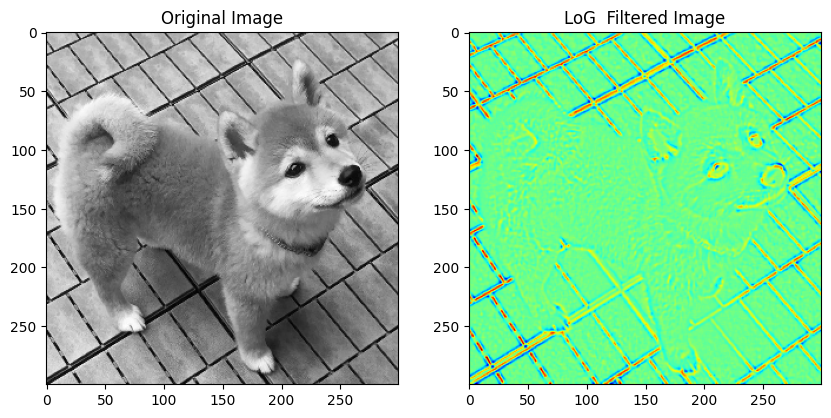

In [70]:
image_blured = cv2.GaussianBlur(image, (0, 0), 1)
# image_gray = cv2.cvtColor(image_blured, cv2.COLOR_BGR2GRAY)
filtered_image = cv2.Laplacian(image_blured, cv2.CV_16S, ksize=3) 
# Plot the original and filtered images
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(122)
plt.imshow(filtered_image, cmap='jet')
plt.title('LoG  Filtered Image')

plt.show()

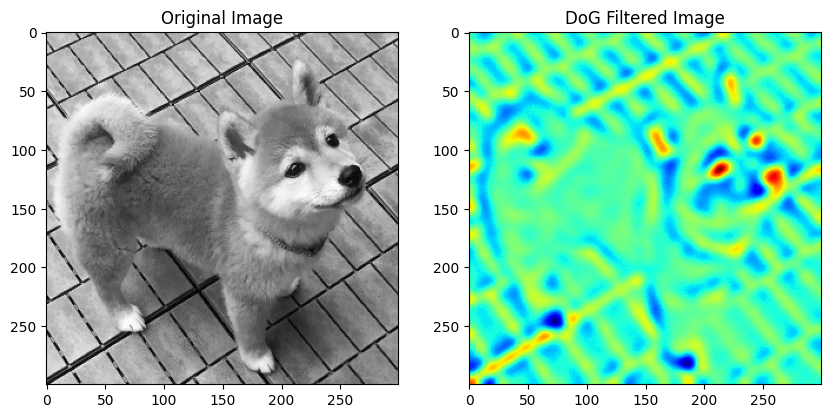

In [80]:
sigma1 = 5
# k = 1.6
# sigma2 = sigma1 / k 
sigma2 = sigma1 * np.sqrt(2) 

# Apply 3x3 and 7x7 Gaussian blur
low_sigma = cv2.GaussianBlur(image, (0,0), sigma2)
high_sigma = cv2.GaussianBlur(image, (0,0), sigma1)
 
# Calculate the DoG by subtracting
dog = low_sigma.astype(np.float32) - high_sigma.astype(np.float32)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(122)
plt.imshow(dog, cmap='jet')
plt.title('DoG Filtered Image')

plt.show()


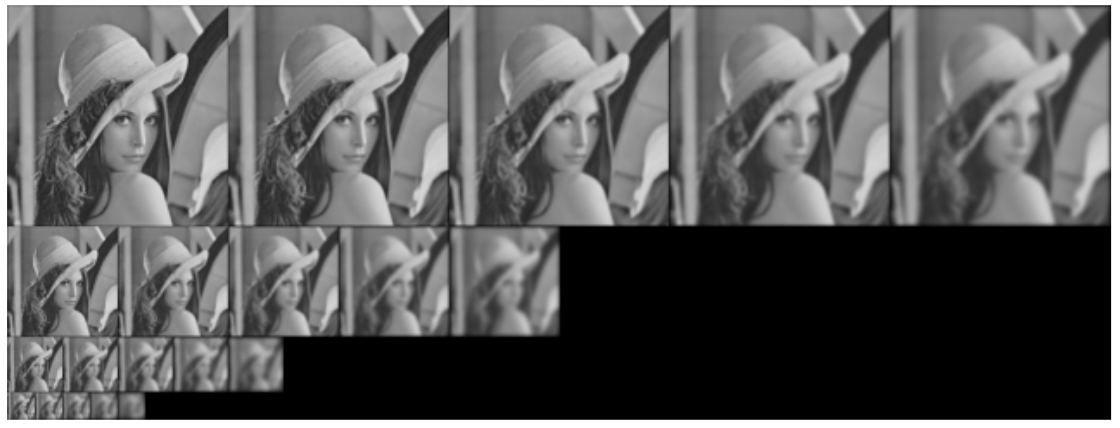

### SIFT (Scale-Invariant Feature Transform) детектор 

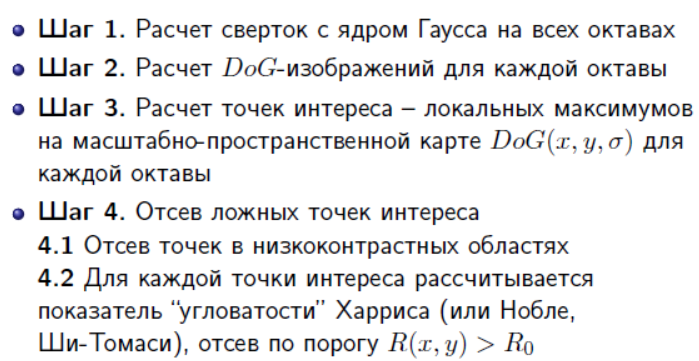

In [88]:
# https://docs.opencv.org/4.x/d7/d60/classcv_1_1SIFT.html

# cv.SIFT_create(	nfeatures, nOctaveLayers, contrastThreshold, edgeThreshold, sigma, descriptorType[, enable_precise_upscale]	) ->	retval
    # nfeatures	The number of best features to retain. The features are ranked by their scores (measured in SIFT algorithm as the local contrast)
    # nOctaveLayers	The number of layers in each octave. 4 is the value used in D. Lowe paper. The number of octaves is computed automatically from the image resolution.
    # contrastThreshold	The contrast threshold used to filter out weak features in semi-uniform (low-contrast) regions. The larger the threshold, the less features are produced by the detector.
    # edgeThreshold	The threshold used to filter out edge-like features. Note that the its meaning is different from the contrastThreshold, i.e. the larger the edgeThreshold, the less features are filtered out (more features are retained).
    # sigma	The sigma of the Gaussian applied to the input image at the octave #0. If your image is captured with a weak camera with soft lenses, you might want to reduce the number.
    # descriptorType	The type of descriptors. Only CV_32F and CV_8U are supported.
    # enable_precise_upscale	Whether to enable precise upscaling in the scale pyramid, which maps index x to 2x. This prevents localization bias. The option is disabled by default.

sift = cv2.SIFT_create( 180 )        # Regarding different parameters, 
                                # the paper gives some empirical data which can be summarized as, 
                                # number of octaves = 4, number of scale levels = 5, initial σ=1.6, k=√2 etc as optimal values.
kp = sift.detect(input_img, None)
image_sift = cv2.drawKeypoints(input_img, kp, image)

image_sift_sc = cv2.drawKeypoints(input_img,kp, image, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)



In [89]:
kp[0].pt, kp[0].angle, kp[0].size, kp[0].response, len(kp)

# https://docs.opencv.org/3.4/d2/d29/classcv_1_1KeyPoint.html

((170.9630889892578, 26.436819076538086),
 87.44192504882812,
 5.773146629333496,
 0.04733770340681076,
 181)

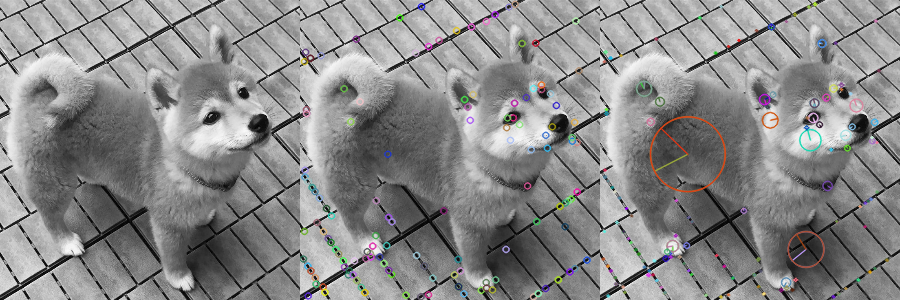

In [90]:
conc = cv2.hconcat( (cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), image_sift, image_sift_sc) )
display(Image.fromarray(conc))

### SURF (Speeded-Up Robust Features). Ускоренный SIFT

In [21]:
# !pip install opencv-contrib-python

In [22]:
# surf = cv2.xfeatures2d.SURF_create(400)
# # Find keypoints and descriptors directly
# kp, des = surf.detectAndCompute(image, None)
# print(len(kp))


### FAST Algorithm for Corner Detection


Feature Detection using FAST
1. Select a pixel $p$ in the image which is to be identified as an interest point or not. Let its intensity be $I_p$.
2. Select appropriate threshold value $t$.
3. Consider a circle of 16 pixels around the pixel under test. (See the image below)

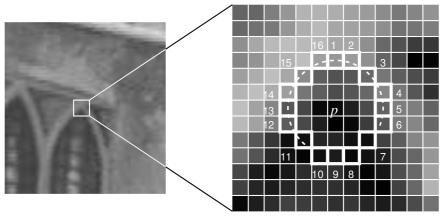

4. Now the pixel $p$ is a corner if there exists a set of $n$ contiguous pixels in the circle (of 16 pixels) which are all brighter than $I_p+t$, or all darker than $I_p−t$. (Shown as white dash lines in the above image). $n$ was chosen to be 12.

5. A high-speed test was proposed to exclude a large number of non-corners. This test examines only the four pixels at 1, 9, 5 and 13 (First 1 and 9 are tested if they are too brighter or darker. If so, then checks 5 and 13). If p is a corner, then at least three of these must all be brighter than Ip+t or darker than Ip−t. If neither of these is the case, then p cannot be a corner. The full segment test criterion can then be applied to the passed candidates by examining all pixels in the circle. This detector in itself exhibits high performance, but there are several weaknesses:

- It does not reject as many candidates for n < 12.
- The choice of pixels is not optimal because its efficiency depends on ordering of the questions and distribution of corner appearances.
- Results of high-speed tests are thrown away.
- Multiple features are detected adjacent to one another.
- First 3 points are addressed with a machine learning approach. Last one is addressed using non-maximal suppression.

https://docs.opencv.org/4.x/df/d0c/tutorial_py_fast.html

In [91]:
# https://docs.opencv.org/3.4/df/d74/classcv_1_1FastFeatureDetector.html

# Initiate FAST object with default values
fast = cv2.FastFeatureDetector_create(70, 1, cv2.FastFeatureDetector_TYPE_9_16)
# find and draw the keypoints
kp = fast.detect(image, None)
image_fast = cv2.drawKeypoints(image, kp, None, color=(0,0,255))
# Print all default params
print( "Threshold: {}".format(fast.getThreshold()) )
print( "nonmaxSuppression:{}".format(fast.getNonmaxSuppression()) )
print( "neighborhood: {}".format(fast.getType()) )
print( "Total Keypoints with nonmaxSuppression: {}".format(len(kp)) )
# Disable nonmaxSuppression
        # setThreshold()
fast.setNonmaxSuppression(0)
kp = fast.detect(image, None)
print( "Total Keypoints without nonmaxSuppression: {}".format(len(kp)) )
image_fast_nonms = cv2.drawKeypoints(image, kp, None, color=(255,0,0))

Threshold: 70
nonmaxSuppression:True
neighborhood: 2
Total Keypoints with nonmaxSuppression: 251
Total Keypoints without nonmaxSuppression: 501


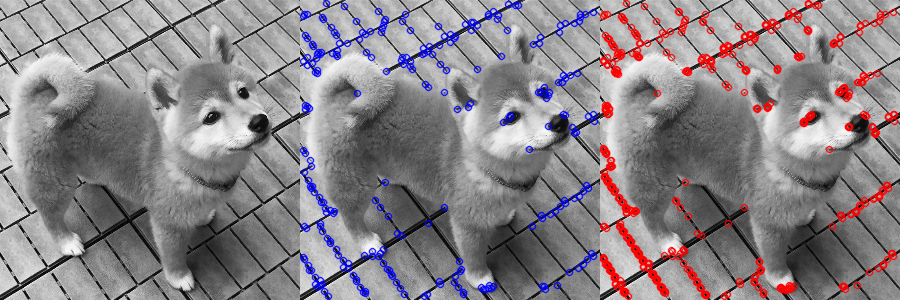

In [93]:
conc = cv2.hconcat( (cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), image_fast, image_fast_nonms) )
display(Image.fromarray(conc))

### MSER

In [25]:
mser = cv2.MSER_create()
kp = mser.detect(image, None)

image_mser = cv2.drawKeypoints(image, kp, None, color=(0,0,255))


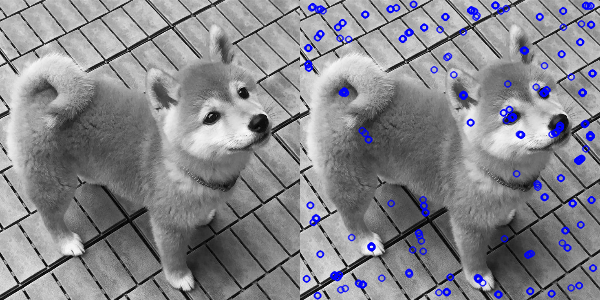

In [26]:
conc = cv2.hconcat( (cv2.cvtColor(input_img, cv2.COLOR_GRAY2RGB), image_mser) )
display(Image.fromarray(conc))

In [94]:
import skimage
